### Question 2:  Did the coupon increase transactions? Did it increase revenues?

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load the AB test data from the Excel file
df_ab = pd.read_excel("Artea Data.xlsx", sheet_name="AB_test")
df_nx = pd.read_excel("Artea Data.xlsx", sheet_name="Next_Campaign")

# Split the dataset into two groups based on test_coupon
#    - Treatment group: received the coupon (test_coupon == 1)
#    - Control group: did NOT receive the coupon (test_coupon == 0)
treatment = df_ab[df_ab["test_coupon"] == 1].copy()
control   = df_ab[df_ab["test_coupon"] == 0].copy()

print("Treatment (coupon) users:", len(treatment))
print("Control (no coupon) users:", len(control))

Treatment (coupon) users: 2502
Control (no coupon) users: 2498


In [2]:
# Average number of transactions made by users who received the coupon
avg_trans_treatment = treatment["trans_after"].mean()

# Average number of transactions made by users who did NOT receive the coupon
avg_trans_control = control["trans_after"].mean()

print("Average transactions after experiment (Treatment - coupon):", avg_trans_treatment)
print("Average transactions after experiment (Control - no coupon):", avg_trans_control)

# Incremental change in transactions due to the coupon
transaction_lift = avg_trans_treatment - avg_trans_control

print("Incremental change in transactions due to coupon:", transaction_lift)

Average transactions after experiment (Treatment - coupon): 0.1518784972022382
Average transactions after experiment (Control - no coupon): 0.1257005604483587
Incremental change in transactions due to coupon: 0.0261779367538795


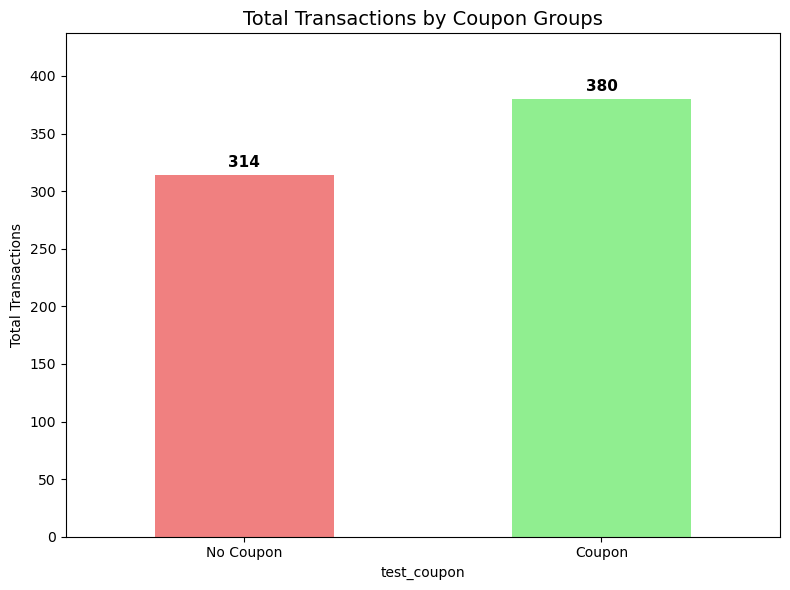

In [3]:
# Group by the coupon test column and sum the transactions
transaction_compare = df_ab.groupby('test_coupon')['trans_after'].sum()

# Plot
ax = transaction_compare.plot(kind='bar', color=['lightcoral', 'lightgreen'], figsize=(8, 6))

# Add the values on top of the bars
for p in ax.patches:
    ax.annotate(f'{p.get_height():}', 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='center', 
                xytext=(0, 9), 
                textcoords='offset points',
                fontsize=11, fontweight='bold')

plt.title('Total Transactions by Coupon Groups', fontsize=14)
plt.ylabel('Total Transactions')
plt.xticks([0, 1], ['No Coupon', 'Coupon'], rotation=0)
plt.ylim(0, transaction_compare.max() * 1.15) # Adds a little extra headroom for the labels
plt.tight_layout()
plt.show()

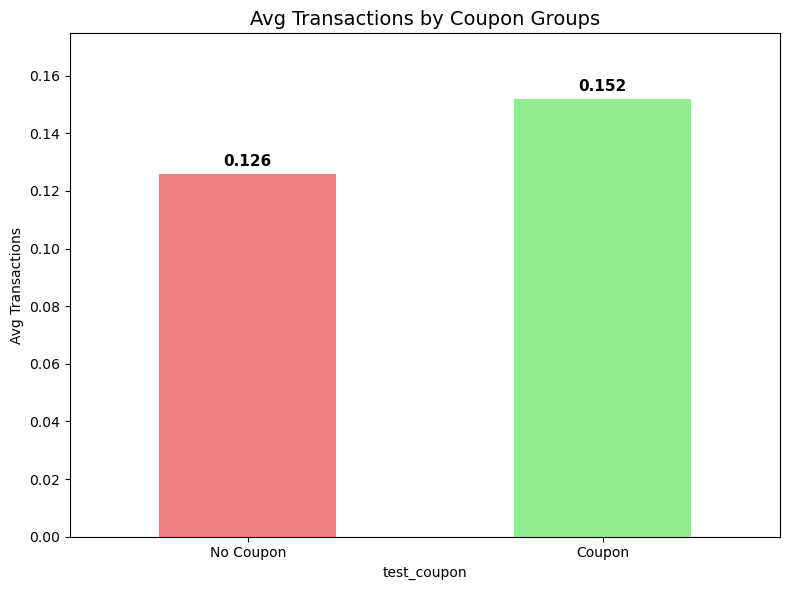

In [4]:
# Average number of transactions after the experiment for each group
transaction_avg_compare = df_ab.groupby('test_coupon')['trans_after'].mean()

# Create the plot and assign it to an 'ax' (axis) variable
ax = transaction_avg_compare.plot(kind='bar', color=['lightcoral', 'lightgreen'], figsize=(8, 6))

# Add the values on top of the bars
for p in ax.patches:
    ax.annotate(f'{p.get_height():,.3f}', 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='center', 
                xytext=(0, 9), 
                textcoords='offset points',
                fontsize=11, fontweight='bold')

# Standard formatting
plt.title('Avg Transactions by Coupon Groups', fontsize=14)
plt.ylabel('Avg Transactions')
plt.xticks([0, 1], ['No Coupon', 'Coupon'], rotation=0)
plt.ylim(0, transaction_avg_compare.max() * 1.15) # Adds a little extra headroom for the labels
plt.tight_layout()
plt.show()

In [5]:
# Average revenue generated by users who received the coupon
avg_rev_treatment = treatment["revenue_after"].mean()

# Average revenue generated by users who did NOT receive the coupon
avg_rev_control = control["revenue_after"].mean()

print("Average revenue after experiment (Treatment - coupon):", avg_rev_treatment)
print("Average revenue after experiment (Control - no coupon):", avg_rev_control)

# Incremental change in revenue due to the coupon
revenue_lift = avg_rev_treatment - avg_rev_control
print("Incremental change in revenue due to coupon:", revenue_lift)

Average revenue after experiment (Treatment - coupon): 7.53867306155076
Average revenue after experiment (Control - no coupon): 7.780168134507607
Incremental change in revenue due to coupon: -0.24149507295684636


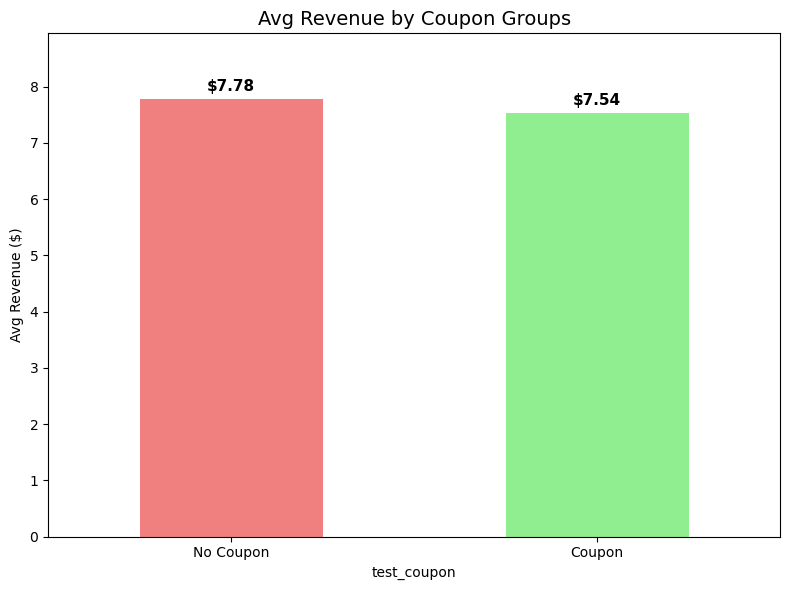

In [6]:
# Average revenue
avg_rev = df_ab.groupby('test_coupon')['revenue_after'].mean()

# Create the plot and assign it to an 'ax' (axis) variable
ax = avg_rev.plot(kind='bar', color=['lightcoral', 'lightgreen'], figsize=(8, 6))

# Add the values on top of the bars
for p in ax.patches:
    ax.annotate(f'${p.get_height():,.2f}', 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='center', 
                xytext=(0, 9), 
                textcoords='offset points',
                fontsize=11, fontweight='bold')

# Standard formatting
plt.title('Avg Revenue by Coupon Groups', fontsize=14)
plt.ylabel('Avg Revenue ($)')
plt.xticks([0, 1], ['No Coupon', 'Coupon'], rotation=0)
plt.ylim(0, avg_rev.max() * 1.15) # Adds a little extra headroom for the labels
plt.tight_layout()
plt.show()

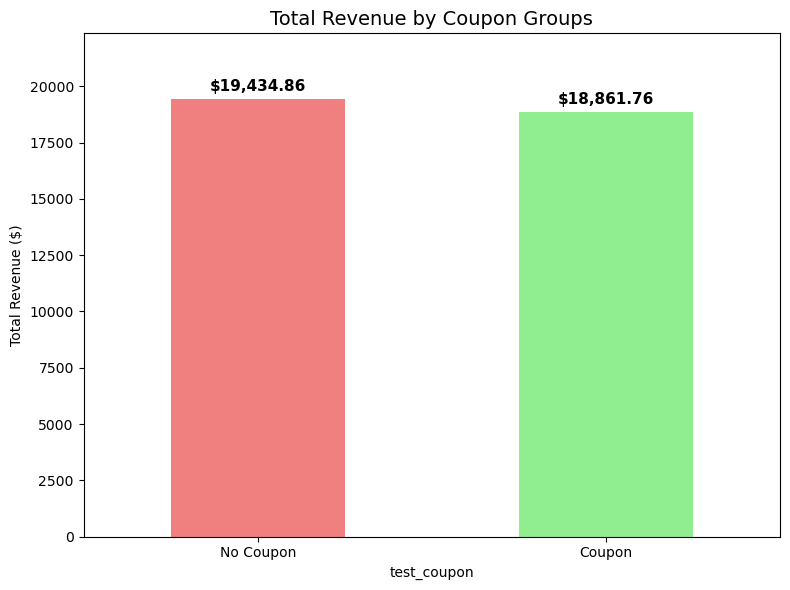

In [7]:
# Group by the coupon test column and sum the revenue 
rev_compare = df_ab.groupby('test_coupon')['revenue_after'].sum()

# Create the plot and assign it to an 'ax' (axis) variable
ax = rev_compare.plot(kind='bar', color=['lightcoral', 'lightgreen'], figsize=(8, 6))

# 3Add the values on top of the bars
for p in ax.patches:
    ax.annotate(f'${p.get_height():,.2f}', 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='center', 
                xytext=(0, 9), 
                textcoords='offset points',
                fontsize=11, fontweight='bold')

# Standard formatting

plt.title('Total Revenue by Coupon Groups', fontsize=14)
plt.ylabel('Total Revenue ($)')
plt.xticks([0, 1], ['No Coupon', 'Coupon'], rotation=0)
plt.ylim(0, rev_compare.max() * 1.15) # Adds a little extra headroom for the labels
plt.tight_layout()
plt.show()

In [10]:
from scipy import stats

# T-test for transactions
t_stat_trans, p_val_trans = stats.ttest_ind(treatment["trans_after"], control["trans_after"])
print("Transaction Significance:")
print(f"T-statistic: {t_stat_trans:.4f}")
print(f"P-value: {p_val_trans:.4f}")
print("Significant?" , "Yes" if p_val_trans < 0.05 else "No")

# T-test for revenue
t_stat_rev, p_val_rev = stats.ttest_ind(treatment["revenue_after"], control["revenue_after"])
print("\nRevenue Significance:")
print(f"T-statistic: {t_stat_rev:.4f}")
print(f"P-value: {p_val_rev:.4f}")
print("Significant?", "Yes" if p_val_rev < 0.05 else "No")

Transaction Significance:
T-statistic: 2.2072
P-value: 0.0273
Significant? Yes

Revenue Significance:
T-statistic: -0.3613
P-value: 0.7179
Significant? No


- The coupon did increase transactions — the average number of transactions for coupon recipients was 0.1519 compared to 0.1257 for the control group, representing a 20.8% increase. This effect is statistically significant (p=0.027), confirming the coupon genuinely drove more purchases and the difference is not due to chance.

- The coupon did not meaningfully increase revenues. Coupon recipients generated an average of \\$7.54 compared to \\$7.78 for the control group, a decrease of $0.24 per user. The p-value of 0.718 confirms this difference is not statistically significant. This makes intuitive sense: while the coupon nudged more people to buy, the 20% discount ate into margins and offset any revenue gains, resulting in no net revenue lift.

### Question 3: Which customers should be targeted in the next targeting campaign? How many transactions and how much revenues would you expect from that targeting strategy? What are the risks of this targeting strategy?
Approach Hybrid (Regression-Informed Segmentation)

Steps:
1. Run regression on A/B data with interaction terms.
2. Identify attributes that significantly affect coupon response.
3. Use those attributes to build meaningful customer segments.
4. Compute uplift within each segment (treatment − control).
5. Rank segments and select those with positive uplift.
6. Apply targeting rule to Next_Campaign dataset.
7. Estimate expected transactions and revenue.

In [11]:
import statsmodels.formula.api as smf
features = [
    'shopping_cart',        # cart activity
    'weeks_since_visit',    # recency
    'browsing_minutes',     # browsing engagement
    'num_past_purch',       # purchase history
    'spent_last_purchase',  # last purchase value
    'channel_acq'           # acquisition channel
]

df_ab_reg = df_ab[features + ['test_coupon', 'trans_after', 'revenue_after']].dropna().copy()

print("Rows used for regression:", len(df_ab_reg))
df_ab_reg.head()

Rows used for regression: 5000


,shopping_cart,weeks_since_visit,browsing_minutes,num_past_purch,spent_last_purchase,channel_acq,test_coupon,trans_after,revenue_after
0,0,6,1,6,62.99,2,0,0,0.0
1,1,0,7,2,53.99,1,1,0,0.0
2,0,3,4,3,88.98,2,1,0,0.0
3,0,1,19,1,68.99,2,0,0,0.0
4,0,4,20,3,66.49,3,1,0,0.0


In [12]:
# Regression to identify attributes that influence coupon effectiveness
# Interaction terms (test_coupon:variable) tell us how the coupon effect
# changes depending on customer characteristics.

rev_model = smf.ols(
    'revenue_after ~ test_coupon + shopping_cart + weeks_since_visit + '
    'browsing_minutes + num_past_purch + spent_last_purchase + C(channel_acq) + '
    'test_coupon:shopping_cart + test_coupon:weeks_since_visit + '
    'test_coupon:browsing_minutes + test_coupon:num_past_purch + '
    'test_coupon:spent_last_purchase + test_coupon:C(channel_acq)',
    data=df_ab_reg
).fit()

# Print regression summary
print(rev_model.summary())

                            OLS Regression Results                            
Dep. Variable:          revenue_after   R-squared:                       0.177
Model:                            OLS   Adj. R-squared:                  0.174
Method:                 Least Squares   F-statistic:                     56.35
Date:                Mon, 09 Mar 2026   Prob (F-statistic):          6.52e-194
Time:                        15:07:53   Log-Likelihood:                -22419.
No. Observations:                5000   AIC:                         4.488e+04
Df Residuals:                    4980   BIC:                         4.501e+04
Df Model:                          19                                         
Covariance Type:            nonrobust                                         
                                      coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------------------
Intercept 

Three interactions are significant. 
- Customers who added items to their shopping cart respond more positively to the coupon (p=0.021), suggesting they need a small nudge to convert.
- Instagram-acquired customers also respond better (p=0.033)in comparison to baseline (channel 1), indicating this segment is more promotion-responsive.
- Customers with more past purchases respond worse (p=0.000), meaning loyal customers would likely have bought anyway, so giving them a discount simply erodes margin.

In [36]:
# Create customer segments using variables that affect coupon response

df_ab_seg = df_ab.copy()

# Cart intent segment
df_ab_seg["Cart_Intent"] = df_ab_seg["shopping_cart"].map({
    1: "Added_to_Cart",
    0: "No_Cart"
})

# Past purchase history segments
df_ab_seg["Past_Purchase_Group"] = pd.cut(
    df_ab_seg["num_past_purch"],
    bins=[-0.001, 0, 2, 5, float("inf")],
    labels=["0 Purchases", "1-2 Purchases", "3-5 Purchases", "6+ Purchases"]
)

# Acquisition channel segment
df_ab_seg["Acquisition_Channel"] = df_ab_seg["channel_acq"].astype(str)

In [37]:
# Compute uplift (treatment − control) for each segment

segment_cols = [
    "Cart_Intent",
    "Past_Purchase_Group",
    "Acquisition_Channel"
]

def uplift_by_segment(df, seg_col):
    # Average outcomes by segment and coupon group
    m = (df.groupby([seg_col, "test_coupon"])[["trans_after", "revenue_after"]]
           .mean()
           .unstack("test_coupon"))

    # Ensure order: control(0), treatment(1)
    m = m.reindex(columns=[0, 1], level=1)

    m.columns = [
        "trans_control",
        "trans_treat",
        "rev_control",
        "rev_treat"
    ]

    # Calculate uplift
    m["transaction_uplift"] = m["trans_treat"] - m["trans_control"]
    m["revenue_uplift"] = m["rev_treat"] - m["rev_control"]

    # Segment size
    m["segment_size"] = df.groupby(seg_col).size()

    return m.reset_index()

# Compute uplift tables for all segmentation variables
uplift_tables = {col: uplift_by_segment(df_ab_seg, col) for col in segment_cols}

# Results
for name, table in uplift_tables.items():
    print(f"\nUplift by {name}")
    print(table.round(3))


Uplift by Cart_Intent
     Cart_Intent  trans_control  trans_treat  rev_control  rev_treat  \
0  Added_to_Cart          0.215        0.292       13.147     14.528   
1        No_Cart          0.087        0.096        5.482      4.742   

   transaction_uplift  revenue_uplift  segment_size  
0               0.077           1.381          1464  
1               0.008          -0.740          3536  

Uplift by Past_Purchase_Group
  Past_Purchase_Group  trans_control  trans_treat  rev_control  rev_treat  \
0         0 Purchases          0.052        0.073        3.156      3.685   
1       1-2 Purchases          0.074        0.116        4.469      5.749   
2       3-5 Purchases          0.147        0.169        9.316      8.112   
3        6+ Purchases          0.550        0.532       34.198     26.811   

   transaction_uplift  revenue_uplift  segment_size  
0               0.020           0.529          1665  
1               0.043           1.280          1830  
2               0.0

C:\Users\sruth\AppData\Local\Temp\ipykernel_37092\963617024.py:11: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  m = (df.groupby([seg_col, "test_coupon"])[["trans_after", "revenue_after"]]
C:\Users\sruth\AppData\Local\Temp\ipykernel_37092\963617024.py:30: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  m["segment_size"] = df.groupby(seg_col).size()


In [38]:
# Identify segments with positive transaction AND revenue uplift
target_segments = {}
for name, table in uplift_tables.items():
    targets = table[
        (table["transaction_uplift"] > 0) &
        (table["revenue_uplift"] > 0)
    ].copy()
    targets = targets.sort_values("revenue_uplift", ascending=False)
    target_segments[name] = targets
    
    print(f"\nTarget segments for {name}")
    print(targets.round(3))


Target segments for Cart_Intent
     Cart_Intent  trans_control  trans_treat  rev_control  rev_treat  \
0  Added_to_Cart          0.215        0.292       13.147     14.528   

   transaction_uplift  revenue_uplift  segment_size  
0               0.077           1.381          1464  

Target segments for Past_Purchase_Group
  Past_Purchase_Group  trans_control  trans_treat  rev_control  rev_treat  \
1       1-2 Purchases          0.074        0.116        4.469      5.749   
0         0 Purchases          0.052        0.073        3.156      3.685   

   transaction_uplift  revenue_uplift  segment_size  
1               0.043           1.280          1830  
0               0.020           0.529          1665  

Target segments for Acquisition_Channel
  Acquisition_Channel  trans_control  trans_treat  rev_control  rev_treat  \
2                   3          0.146        0.205        9.172     10.337   
1                   2          0.159        0.221        9.815     10.895   
3      

**Target customers who satisfy all three conditions:**

1. Added items to the shopping cart
2. Have 0 to 2 past purchases
3. Were acquired via Facebook, Instagram, or Referral

In [39]:
# Apply targeting rule to the Next_Campaign dataset
df_nx_seg = df_nx.copy()
# Create same segments as AB data
df_nx_seg["Cart_Intent"] = df_nx_seg["shopping_cart"].map({
    1: "Added_to_Cart",
    0: "No_Cart"
})

df_nx_seg["Past_Purchase_Group"] = pd.cut(
    df_nx_seg["num_past_purch"],
    bins=[-0.001, 0, 2, 5, float("inf")],
    labels=["0 Purchases", "1-2 Purchases", "3-5 Purchases", "6+ Purchases"]
)

df_nx_seg["Acquisition_Channel"] = df_nx_seg["channel_acq"].astype(str)

# Apply targeting rule
target_customers = df_nx_seg[
    (df_nx_seg["Cart_Intent"] == "Added_to_Cart") &
    (df_nx_seg["Past_Purchase_Group"].isin(["0 Purchases", "1-2 Purchases"])) &
    (df_nx_seg["Acquisition_Channel"].isin(["2","3","4"]))
].copy()

print("Total customers in Next Campaign:", len(df_nx_seg))
print("Customers to target:", len(target_customers))
print("Targeting rate:", round(len(target_customers)/len(df_nx_seg)*100,2), "%")

Total customers in Next Campaign: 6000
Customers to target: 668
Targeting rate: 11.13 %


In [40]:
# Estimate expected incremental transactions and revenue
target_size = len(target_customers)

# Uplift from AB test (Cart Intent segment)
transaction_uplift = 0.077
revenue_uplift = 1.381

expected_transactions = target_size * transaction_uplift
expected_revenue = target_size * revenue_uplift

print("Expected incremental impact of targeting strategy:")
print("Customers targeted:", target_size)
print("Expected incremental transactions:", round(expected_transactions,2))
print("Expected incremental revenue ($):", round(expected_revenue,2))

# Baseline revenue (control average for Added_to_Cart segment)
baseline_revenue_per_customer = 13.147
total_revenue = target_size * baseline_revenue_per_customer + expected_revenue
print("Expected total revenue ($):", round(total_revenue, 2))

Expected incremental impact of targeting strategy:
Customers targeted: 668
Expected incremental transactions: 51.44
Expected incremental revenue ($): 922.51
Expected total revenue ($): 9704.7


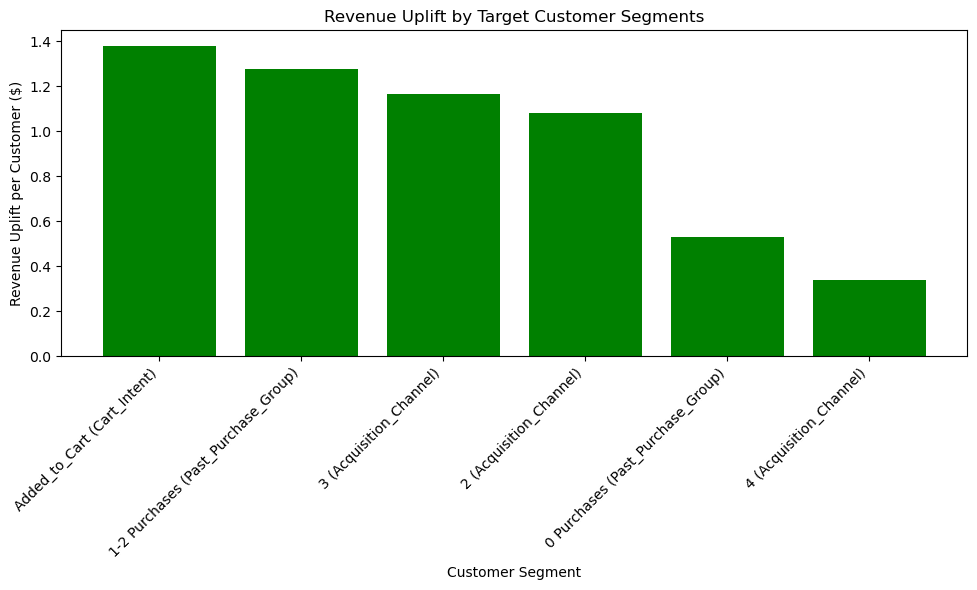

In [42]:
# Combine the positive target segments into one dataframe for visualization
plot_df = pd.concat([
    target_segments["Cart_Intent"].assign(variable="Cart_Intent", segment=lambda x: x["Cart_Intent"]),
    target_segments["Past_Purchase_Group"].assign(variable="Past_Purchase_Group", segment=lambda x: x["Past_Purchase_Group"]),
    target_segments["Acquisition_Channel"].assign(variable="Acquisition_Channel", segment=lambda x: x["Acquisition_Channel"])
])

plot_df = plot_df.sort_values(by="revenue_uplift", ascending=False)
plt.figure(figsize=(10,6))
plt.bar(
    plot_df["segment"].astype(str) + " (" + plot_df["variable"] + ")",
    plot_df["revenue_uplift"],
    color="green"
)

plt.xticks(rotation=45, ha="right")
plt.ylabel("Revenue Uplift per Customer ($)")
plt.xlabel("Customer Segment")
plt.title("Revenue Uplift by Target Customer Segments")

plt.tight_layout()
plt.show()

### 4. What do you learn from the demographics data? Would you change change the targeting policy from the first part of the case?

=== Dataset Overview ===
Total customers: 5000

Minority distribution:
minority
0    3958
1    1042
Name: count, dtype: int64
Minority %: 20.8%

Non-male distribution:
non_male
1    2900
0    2100
Name: count, dtype: int64
Non-male %: 58.0%

=== Avg Transactions by Minority x Coupon ===
minority  test_coupon
0         0              0.136
          1              0.173
1         0              0.085
          1              0.070
Name: trans_after, dtype: float64

=== Avg Revenue by Minority x Coupon ===
minority  test_coupon
0         0              8.425
          1              8.616
1         0              5.367
          1              3.384
Name: revenue_after, dtype: float64

=== Avg Transactions by Non_Male x Coupon ===
non_male  test_coupon
0         0              0.117
          1              0.134
1         0              0.132
          1              0.165
Name: trans_after, dtype: float64

=== Avg Revenue by Non_Male x Coupon ===
non_male  test_coupon
0         0      

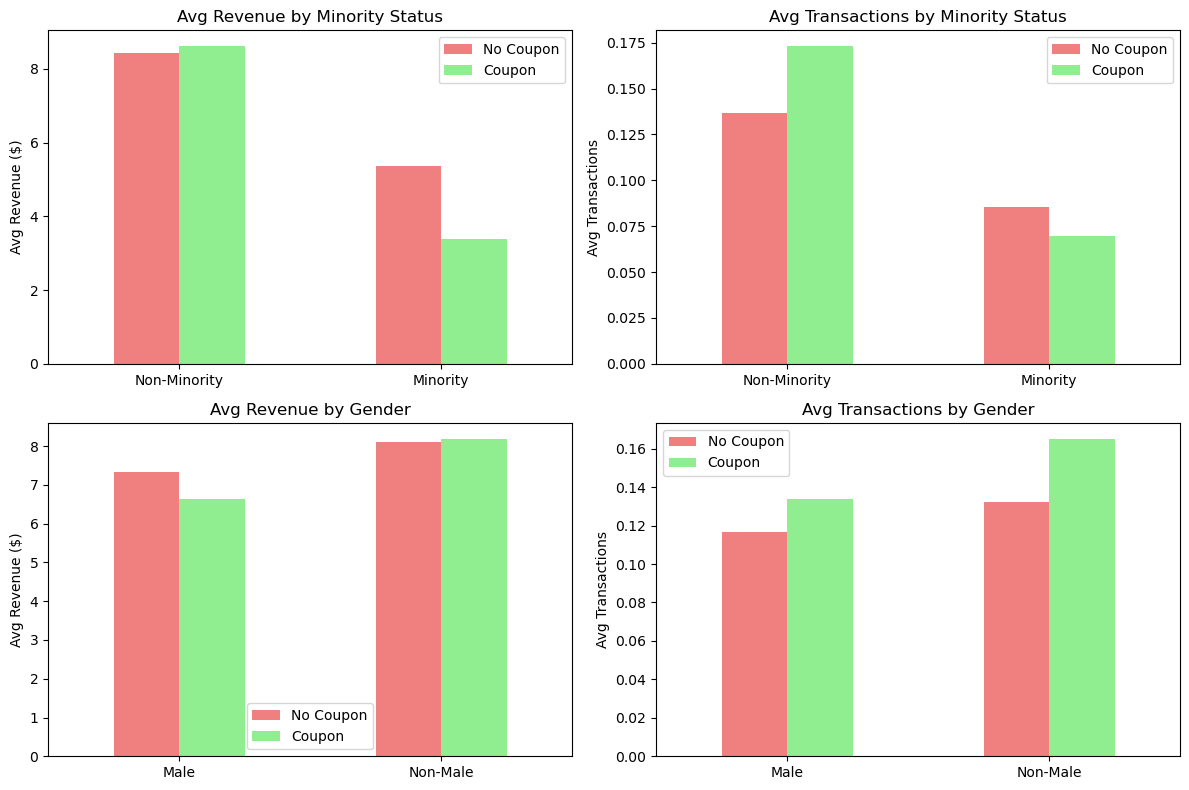

In [33]:
import pandas as pd
import matplotlib.pyplot as plt

df_b = pd.read_excel("Artea (B) Data.xlsx", sheet_name="AB_test_demog")
df_nx_b = pd.read_excel("Artea (B) Data.xlsx", sheet_name="Next_Campaign_demog")

# Distribution of demographic variables
print("=== Dataset Overview ===")
print("Total customers:", len(df_b))
print("\nMinority distribution:")
print(df_b['minority'].value_counts())
print(f"Minority %: {df_b['minority'].mean()*100:.1f}%")

print("\nNon-male distribution:")
print(df_b['non_male'].value_counts())
print(f"Non-male %: {df_b['non_male'].mean()*100:.1f}%")

# Average transactions and revenue by demographic group
print("\n=== Avg Transactions by Minority x Coupon ===")
print(df_b.groupby(['minority','test_coupon'])['trans_after'].mean().round(3))

print("\n=== Avg Revenue by Minority x Coupon ===")
print(df_b.groupby(['minority','test_coupon'])['revenue_after'].mean().round(3))

print("\n=== Avg Transactions by Non_Male x Coupon ===")
print(df_b.groupby(['non_male','test_coupon'])['trans_after'].mean().round(3))

print("\n=== Avg Revenue by Non_Male x Coupon ===")
print(df_b.groupby(['non_male','test_coupon'])['revenue_after'].mean().round(3))

# Visualizations
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

# Revenue by minority
rev_minority = df_b.groupby(['minority','test_coupon'])['revenue_after'].mean().unstack()
rev_minority.plot(kind='bar', ax=axes[0,0], color=['lightcoral','lightgreen'])
axes[0,0].set_title('Avg Revenue by Minority Status')
axes[0,0].set_xlabel('')
axes[0,0].set_xticklabels(['Non-Minority','Minority'], rotation=0)
axes[0,0].legend(['No Coupon','Coupon'])
axes[0,0].set_ylabel('Avg Revenue ($)')

# Transactions by minority
trans_minority = df_b.groupby(['minority','test_coupon'])['trans_after'].mean().unstack()
trans_minority.plot(kind='bar', ax=axes[0,1], color=['lightcoral','lightgreen'])
axes[0,1].set_title('Avg Transactions by Minority Status')
axes[0,1].set_xlabel('')
axes[0,1].set_xticklabels(['Non-Minority','Minority'], rotation=0)
axes[0,1].legend(['No Coupon','Coupon'])
axes[0,1].set_ylabel('Avg Transactions')

# Revenue by non_male
rev_nonmale = df_b.groupby(['non_male','test_coupon'])['revenue_after'].mean().unstack()
rev_nonmale.plot(kind='bar', ax=axes[1,0], color=['lightcoral','lightgreen'])
axes[1,0].set_title('Avg Revenue by Gender')
axes[1,0].set_xlabel('')
axes[1,0].set_xticklabels(['Male','Non-Male'], rotation=0)
axes[1,0].legend(['No Coupon','Coupon'])
axes[1,0].set_ylabel('Avg Revenue ($)')

# Transactions by non_male
trans_nonmale = df_b.groupby(['non_male','test_coupon'])['trans_after'].mean().unstack()
trans_nonmale.plot(kind='bar', ax=axes[1,1], color=['lightcoral','lightgreen'])
axes[1,1].set_title('Avg Transactions by Gender')
axes[1,1].set_xlabel('')
axes[1,1].set_xticklabels(['Male','Non-Male'], rotation=0)
axes[1,1].legend(['No Coupon','Coupon'])
axes[1,1].set_ylabel('Avg Transactions')

plt.tight_layout()
plt.show()

In [34]:
import statsmodels.formula.api as smf

# Regression with demographic interaction terms
rev_model_b = smf.ols(
    'revenue_after ~ test_coupon + minority + non_male + '
    'shopping_cart + weeks_since_visit + browsing_minutes + '
    'num_past_purch + spent_last_purchase + C(channel_acq) + '
    'test_coupon:minority + test_coupon:non_male + '
    'test_coupon:shopping_cart + test_coupon:weeks_since_visit + '
    'test_coupon:browsing_minutes + test_coupon:num_past_purch + '
    'test_coupon:spent_last_purchase + test_coupon:C(channel_acq)',
    data=df_b
).fit()

print(rev_model_b.summary())

                            OLS Regression Results                            
Dep. Variable:          revenue_after   R-squared:                       0.179
Model:                            OLS   Adj. R-squared:                  0.175
Method:                 Least Squares   F-statistic:                     47.09
Date:                Mon, 09 Mar 2026   Prob (F-statistic):          9.36e-193
Time:                        18:05:08   Log-Likelihood:                -22414.
No. Observations:                5000   AIC:                         4.488e+04
Df Residuals:                    4976   BIC:                         4.503e+04
Df Model:                          23                                         
Covariance Type:            nonrobust                                         
                                      coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------------------
Intercept 

The demographic interaction terms (test_coupon:minority and test_coupon:non_male)
are both insignificant (p=0.639 and p=0.164 respectively), meaning the coupon
effect does not statistically differ by minority status or gender.
Although exploratory analysis showed minority customers had lower revenue in the
treatment group, the regression confirms this pattern is not statistically robust.
Therefore, the targeting policy from Part A does not need to change —
shopping cart activity and past purchases remain the key targeting variables.